In [102]:
import numpy as np
import matplotlib.pyplot as plt

In [103]:
class Particle:

    def __init__(self, m, z, p, *args): 
        """
        m: is the mass of the particle in MeV/c^2\n
        z: is the charge of the particle in unit of e\n
        p: is the 3-momenta of the particle in unit of MeV/c\n
        """
        if m < 0:
            raise ValueError('Mass must be positive')
        if (type(z) is not int):
            raise ValueError("Charge must be in units of 'e'")
        self.m_, self.z_, self.p_ = m, z, np.array(p)
        if self.p_.size != 3:
            raise IndexError("Array must be 3-dimensional")

#Getters
    def getMass(self):
        """Returns the mass of the partcle"""
        return self.m_

    def getCharge(self):
        """Returns the charge of the particle in units of 'e'"""
        return self.z_

    def getMomenta(self):
        """Returns the momenta 3-Vector of the particle"""
        return np.array(self.p_)

#Setters
    def setMass(self, m):
        """Set the particle's mass in MeV/c^2"""
        if m < 0:
            raise ValueError('Mass must be positive')
        self.m_ = m
    
    def setCharge(self, z):
        """Set the particle's charge in units of e"""
        if (type(z) is not int):
            raise ValueError("Charge must be in units of 'e'")
        self.z_ = z
    
    def setMomenta(self, p):
        """Set the particle's 3-momenta in MeV/c"""
        self.p_ = np.array(p)
        if self.p_.size !=3:
            raise IndexError("Array must be 3-dimensional")

#other methods
    def beta(self):
        """returns velocity/(speed of light) of the particle"""
        p_mod = np.linalg.norm(self.p_)
        return p_mod/np.sqrt(p_mod*p_mod+self.m_*self.m_)
    
    def E(self): 
        """Returns the kinetic energy of the partile in MeV"""
        return self.m_*(1/np.sqrt(1-self.beta()*self.beta())-1)
    
    def Print(self):
        """Prints particle's informations"""
        print(f"The particle has the following attributes: \nMass: %.3f MeV/c^2 \nCharge: %d e \nBeta: %.4f\nKinetic Energy: %.4f MeV" % (self.m_, self.z_, self.beta(), self.E()))
        print('Momentum:', self.p_,' MeV/c')

In [104]:
electron = Particle(0.511, -1, [5.5,0,0])
electron.Print()

The particle has the following attributes: 
Mass: 0.511 MeV/c^2 
Charge: -1 e 
Beta: 0.9957
Kinetic Energy: 5.0127 MeV
Momentum: [5.5 0.  0. ]  MeV/c


In [105]:
class Barrier :

    def __init__(self, P, rho, A, Z, I, *args):
        """
        P: is the particle instance inside the material\n
        rho: is the material's density (g/cm^3)\n
        A: is the material's atomic mass\n
        Z: is the material's atomic number\n
        I: is the material's excitation energy (eV)
        """
        if (type(A) is not int or A < 0):
            raise ValueError("Atomic mass must be positive and an integer")
        if (type(Z) is not int or Z < 0):
            raise ValueError("Atomic number must be positive and an integer")
        if (I < 0):
            raise ValueError("Atomic excitation energy must be positive")
        if (rho < 0):
            raise ValueError("Material's density must be positive")
        self.rho_, self.A_, self.Z_, self.I_ = rho, A, Z, I
        if (type(P) is not Particle):
            raise TypeError("The particle must be a class Particle's instance")
        self.P_ = P
    
    #Getters
    def getAtomicMass(self):
        """Returns the material's atomic mass"""
        return self.A_
    
    def getAtomicNumber(self):
        """Returns the material's atomic number"""
        return self.Z_
    
    def getDensity(self):
        """Returns the material's density in g/cm^3"""
        return self.rho_
    
    def getExcitationE(self):
        """Returns the material's excitation Energy in eV"""
        return self.I_
    
    def getParticleInfo(self):
        """Uses the print method of Particle"""
        self.P_.Print()
    
    #Setters
    def setAtomicMass(self, A):
        """Set the material's atomic mass"""
        if (type(A) is not int or A < 0):
            raise ValueError("Atomic mass must be positive and an integer")
        self.A_ = A
    
    def setAtomicNumber(self, Z):
        """Set the material's atomic number"""
        if (type(Z) is not int or Z < 0):
            raise ValueError("Atomic number must be positive and an integer")
        self.Z_ = Z
    
    def setDensity(self, rho):
        """Set the material's density"""
        if (rho < 0):
            raise ValueError("Material's density must be positive")

        self.rho_ = rho

    def setExcitationE(self, I):
        """Set the material's excitation energy"""
        if (I < 0):
            raise ValueError("Atomic excitation energy must be positive")
        self.I_ = I
    
    def setParticle(self, P):
        """Set the particle inside the material"""
        if (type(P) is not Particle):
            raise TypeError("The particle must be a class Particle's instance")
        self.P_= P
    
    #Other Methods 
    def S(self):
        """Returns the stopping power of the material in eV*g/cm^3"""
        e=1.6e-19 #Electron's charge
        Na= 6.022e23 #Avogadro's number
        eps0=8.854e-12 #Vacuum permittivity 
        me=0.511 #Electron's mass in MeV/c^2

        beta = self.P_.beta() #I store the beta value, for better performances and better looking code
        #I divide the formula in two parts:
        temp1 = ((e*e*e*e)*(self.P_.getCharge()*self.P_.getCharge())*Na*self.Z_*self.rho_)/(4*np.pi*eps0*eps0*(me*1.6e-13)*(beta*beta*self.A_))
        temp2 = np.log((2*me*1e6*beta*beta)/(self.I_*(1-beta*beta)))-beta*beta
        return temp1*temp2/(e)
    
    def Print(self):
        """Prints the material's informations"""
        print(f"Barrier's informations: \nDensity: %.2f g/cm^3\nAtomic Mass: %d \nAtomic Number: %d nExcitation Energy: %.2f eV" % (self.rho_, self.A_, self.Z_, self.I_))

In [106]:
params = [2.2, 12, 6, 81]
carbon = Barrier(electron, params[0], params[1], params[2], params[3])
carbon.Print()
print(f"Material's stopping power on the electron: %.2f eV*g/cm^3" % (carbon.S()))

Barrier's informations: 
Density: 2.20 g/cm^3
Atomic Mass: 12 
Atomic Number: 6 nExcitation Energy: 81.00 eV
Material's stopping power on the electron: 448.63 eV*g/cm^3


In [ ]:
#Compute the values of Linear stopping power per electron's energy

electron.setMomenta([0,0,0])
N=10000 #number of iterations
dp = 0.001 #increments of the electron's momenta
values=[] #array that will have shape (N,2), carrying E and S
for i in range(N):
    electron.setMomenta([(i+401)*dp,0,0]) #I skip the first values where it explodes
    values.append([electron.E(), carbon.S()])
values = np.array(values)
print(values.shape) #check if the dimensionality is correct

(10000, 2)


In [178]:
#Do the same but with an helium projectile
helium = Particle(938, 2, [0,0,0])
carbon = Barrier(helium, params[0], params[1], params[2], params[3])

N=10000 #number of iterations
dp = 1 #increments of the electron's momenta
values2=[] #array that will have shape (N,2), carrying E and S
for i in range(N):
    helium.setMomenta([(i+1001)*dp,0,0]) #I skip the first values where it explodes
    values2.append([helium.E(), carbon.S()])
values2 = np.array(values2)
print(values2.shape) #check if the dimensionality is correct

(10000, 2)


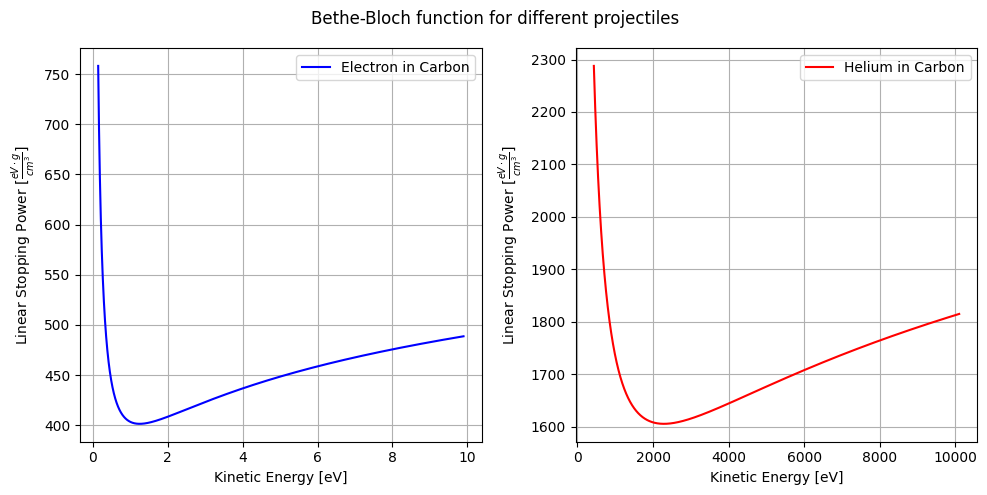

In [ ]:
#plot the energy loss per unit length of electron in carbon material
#remember this prediciton is incorrect since bethe bloch doesn't work on particles with mass near the electron's

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(121)

#plot the electron's bethe bloch
ax.plot(values[:,0], values[:,1], color='blue', label='Electron in Carbon')
ax.set_xlabel("Kinetic Energy [eV]")
ax.set_ylabel("Linear Stopping Power [$\\frac{eV\\cdot g}{cm^3}$]")
plt.suptitle("Bethe-Bloch function for different projectiles")
ax.grid()
ax.legend()

#plot the helium's bethe bloch
ax = fig.add_subplot(122)
ax.plot(values2[:,0], values2[:,1], color='red', label='Helium in Carbon')
ax.set_xlabel("Kinetic Energy [eV]")
ax.set_ylabel("Linear Stopping Power [$\\frac{eV\\cdot g}{cm^3}$]")
ax.grid()
ax.legend()
fig.tight_layout()